In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [161]:
# load_titanic_dataset form kaggle
df = pd.read_csv("/content/tested.csv")
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [162]:
# dimension of dataset
df.shape

(418, 12)

In [163]:
# count no of null values in load dataset
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [164]:
#fix the null values
df['Age'] = df['Age'].fillna(df['Age'].median())
df["Fare"] = df['Fare'].fillna(df["Fare"].mean())
df["Cabin"]= df["Cabin"].fillna("unknown")

In [165]:
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,unknown,S
5,897,0,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,unknown,S
6,898,1,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,unknown,Q
7,899,0,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,unknown,S
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,unknown,C
9,901,0,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,unknown,S


In [166]:
# basic info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          418 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         418 non-null    float64
 10  Cabin        418 non-null    object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [167]:
# common statistics of load dataset
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,1100.500000,0.363636,2.265550,29.599282,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,12.703770,0.896760,0.981429,55.840500
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,23.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,35.750000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [168]:
# separate data type of columns
cate_col = [col for col in df.columns if df[col].dtype =='object']
num_col =  [col for col in df.columns if df[col].dtype !='object']
print("categorical dtye :",cate_col)
print("numerical dtye :",num_col)

categorical dtye : ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
numerical dtye : ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [169]:
survival_means = df.groupby("Sex")["Survived"].mean()
print("survival rate by age group : ", survival_means)

survival rate by age group :  Sex
female    1.0
male      0.0
Name: Survived, dtype: float64


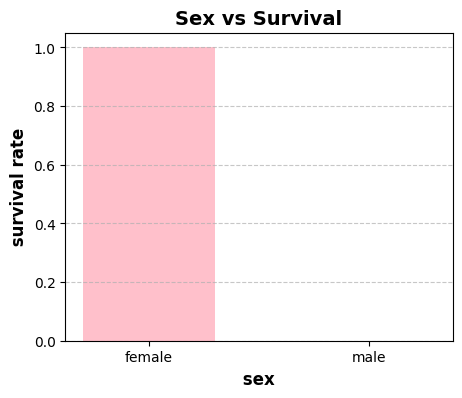

In [170]:
# ploting  with certain relation
fig = plt.figure(figsize=(5,4))

plt.bar(survival_means.index, survival_means.values, color=["pink", "blue"],width=0.6)
plt.title("Sex vs Survival", fontsize = 14,fontweight='bold')
plt.ylabel(" survival rate ",fontsize = 12,fontweight='bold')
plt.xlabel(" sex ",fontsize = 12,fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [171]:
survival_class = df.groupby("Pclass")["Survived"].mean()
print("survival chances by pclass :",survival_class)



survival chances by pclass : Pclass
1    0.467290
2    0.322581
3    0.330275
Name: Survived, dtype: float64


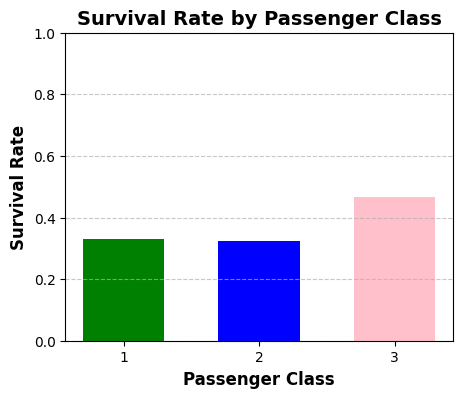

In [172]:
#Bar chart of survival by class.
fig = plt.figure(figsize=(5,4))

plt.bar(df["Pclass"].unique(), df.groupby("Pclass")["Survived"].mean(), color=["pink", "blue","green"],width=0.6)
plt.title("Survival Rate by Passenger Class", fontsize=14, fontweight='bold')
plt.ylabel("Survival Rate", fontsize=12,fontweight='bold')
plt.xlabel("Passenger Class", fontsize=12,fontweight='bold')
plt.xticks([1, 2, 3]) # Ensures only class 1, 2, and 3 are shown
plt.ylim(0, 1)         # Probability is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [173]:
# count no_ages of paticular range
age_range={ "10": 0,"20": 0,"30": 0,"40": 0,"50": 0,"60": 0,"70": 0}
for a in df["Age"]:
  if a <=10 :
    age_range["10"] +=1
  elif a <=20 :
    age_range["20"] +=1
  elif a <=30 :
    age_range["30"] +=1
  elif a <=40 :
    age_range["40"] +=1
  elif a <=50 :
    age_range["50"] +=1
  elif a <=60 :
    age_range["60"] +=1
  elif a <=70 :
    age_range["70"] +=1
age_list = pd.Series(age_range)
print("age_range -")
print(age_list)


age_range -
10     22
20     47
30    217
40     55
50     46
60     20
70     10
dtype: int64


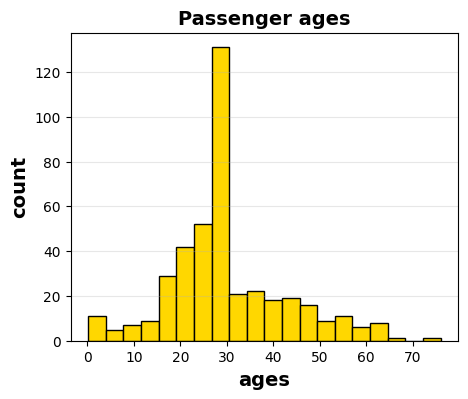

In [174]:
#Histogram of passenger ages.
fig = plt.figure(figsize = (5,4))

plt.hist(df["Age"],bins=20,color='gold', edgecolor='black')
plt.title("Passenger ages", fontsize=14, fontweight="bold")
plt.xlabel("ages", fontsize=14, fontweight="bold")
plt.ylabel("count", fontsize=14, fontweight="bold")
plt.grid(axis='y', alpha=0.3)
plt.show()